# 📊 Explorando activos financieros con Python y pandas
## Análisis exploratorio de activos de un portafolio

En este laboratorio aprenderás a obtener datos financieros, explorarlos con **pandas**, transformarlos y encontrar información útil para analizar activos.

> **Idea clave:** primero observamos los datos, después calculamos y finalmente interpretamos.


## 🧭 Ruta de aprendizaje

**1. Conectar con los datos** → Yahoo Finance y tickers  
**2. Conocer la información** → DataFrame y estructura  
**3. Mirar antes de calcular** → exploración inicial  
**4. Seguir el comportamiento** → precios y gráficos  
**5. Medir los cambios** → rendimientos  
**6. Describir lo encontrado** → estadísticas  
**7. Comparar para comprender** → varios activos  
**8. Buscar relaciones** → correlación  
**9. Tu análisis** → misión individual


# 1. 🔌 Conectar con los datos

### ¿De dónde obtenemos la información?

Yahoo Finance contiene información histórica de diferentes activos financieros. Para acceder a ella desde Python utilizaremos **yfinance**.

Un **ticker** es el código utilizado para identificar un activo. Por ejemplo: `AAPL`, `MSFT`, `AMZN` o `GOOGL`.


In [11]:
!pip -q install yfinance

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Activos asignados

Trabajaremos con los seis activos indicados:

`MSFT`, `BAC`, `PSX`, `PFE`, `PG` y `MMM`.

Los datos se consultarán desde Yahoo Finance para el período comprendido entre el **1 de enero de 2020 y el 1 de enero de 2025**.

In [12]:
# Activos asignados
tickers = ["MSFT", "BAC", "PSX", "PFE", "PG", "MMM"]

# Descargar los datos históricos
datos = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False,
    group_by="column",
    progress=False
)

datos.head()

Price       Adj Close                                                 \
Ticker            BAC         MMM        MSFT        PFE          PG   
Date                                                                   
2020-01-02  30.274990  119.004311  151.544250  26.583315  103.959297   
2020-01-03  29.646389  117.979538  149.657242  26.440687  103.260117   
2020-01-06  29.603905  118.091934  150.044128  26.406725  103.403320   
2020-01-07  29.408535  117.615929  148.676010  26.318432  102.763100   
2020-01-08  29.705851  119.420807  151.044235  26.528980  103.201157   

Price                      Close                                     ...  \
Ticker            PSX        BAC         MMM        MSFT        PFE  ...   
Date                                                                 ...   
2020-01-02  85.790741  35.639999  150.501678  160.619995  37.134724  ...   
2020-01-03  82.953995  34.900002  149.205688  158.619995  36.935486  ...   
2020-01-06  82.434044  34.849998  149.347824  159.029999  36.888046  ...   
2020-01-07  82.686386  34.619999  148.745819  157.580002  36.764706  ...   
2020-01-08  79.597305  34.970001  151.028427  160.089996  37.058823  ...   

Price             Open                                       Volume           \
Ticker            MSFT        PFE          PG         PSX       BAC      MMM   
Date                                                                           
2020-01-02  158.779999  37.286530  124.500000  112.080002  37614200  4307633   
2020-01-03  158.320007  36.736244  122.160004  111.250000  50357900  2950412   
2020-01-06  157.080002  36.831120  122.570000  108.239998  42185000  2389608   
2020-01-07  159.320007  37.115749  122.879997  107.129997  34149000  2598908   
2020-01-08  158.929993  36.774193  122.190002  108.320000  45311600  3298927   

Price                                             
Ticker          MSFT       PFE       PG      PSX  
Date                                              
2020-01-02  22622100  16514072  8130800  1607900  
2020-01-03  21116200  14922848  7970500  2236900  
2020-01-06  20813700  15771951  6674400  3917100  
2020-01-07  21634100  20108107  7583400  2687900  
2020-01-08  27746500  16403507  5385100  3452600  

[5 rows x 36 columns]

# 2. 🧩 Conocer la información

Lo que acabamos de obtener es un **DataFrame de pandas**: una estructura de datos organizada en filas y columnas.

Antes de analizar, necesitamos saber qué contiene la tabla y cómo está organizada.


In [13]:
datos.head()

Price       Adj Close                                                 \
Ticker            BAC         MMM        MSFT        PFE          PG   
Date                                                                   
2020-01-02  30.274990  119.004311  151.544250  26.583315  103.959297   
2020-01-03  29.646389  117.979538  149.657242  26.440687  103.260117   
2020-01-06  29.603905  118.091934  150.044128  26.406725  103.403320   
2020-01-07  29.408535  117.615929  148.676010  26.318432  102.763100   
2020-01-08  29.705851  119.420807  151.044235  26.528980  103.201157   

Price                      Close                                     ...  \
Ticker            PSX        BAC         MMM        MSFT        PFE  ...   
Date                                                                 ...   
2020-01-02  85.790741  35.639999  150.501678  160.619995  37.134724  ...   
2020-01-03  82.953995  34.900002  149.205688  158.619995  36.935486  ...   
2020-01-06  82.434044  34.849998  149.347824  159.029999  36.888046  ...   
2020-01-07  82.686386  34.619999  148.745819  157.580002  36.764706  ...   
2020-01-08  79.597305  34.970001  151.028427  160.089996  37.058823  ...   

Price             Open                                       Volume           \
Ticker            MSFT        PFE          PG         PSX       BAC      MMM   
Date                                                                           
2020-01-02  158.779999  37.286530  124.500000  112.080002  37614200  4307633   
2020-01-03  158.320007  36.736244  122.160004  111.250000  50357900  2950412   
2020-01-06  157.080002  36.831120  122.570000  108.239998  42185000  2389608   
2020-01-07  159.320007  37.115749  122.879997  107.129997  34149000  2598908   
2020-01-08  158.929993  36.774193  122.190002  108.320000  45311600  3298927   

Price                                             
Ticker          MSFT       PFE       PG      PSX  
Date                                              
2020-01-02  22622100  16514072  8130800  1607900  
2020-01-03  21116200  14922848  7970500  2236900  
2020-01-06  20813700  15771951  6674400  3917100  
2020-01-07  21634100  20108107  7583400  2687900  
2020-01-08  27746500  16403507  5385100  3452600  

[5 rows x 36 columns]

In [14]:
datos.tail()

Price       Adj Close                                                 \
Ticker            BAC         MMM        MSFT        PFE          PG   
Date                                                                   
2024-12-24  42.690811  126.165222  433.363525  23.711872  161.007736   
2024-12-26  42.854336  126.958824  432.160065  23.552256  162.170456   
2024-12-27  42.652332  125.990997  424.683105  23.605461  161.570053   
2024-12-30  42.238697  124.974808  419.060455  23.428110  159.244614   
2024-12-31  42.277172  124.936089  415.775696  23.525654  159.778275   

Price                       Close                                     ...  \
Ticker             PSX        BAC         MMM        MSFT        PFE  ...   
Date                                                                  ...   
2024-12-24  105.338882  44.380001  130.360001  439.329987  26.740000  ...   
2024-12-26  105.924210  44.549999  131.179993  438.109985  26.559999  ...   
2024-12-27  106.292381  44.340000  130.179993  430.529999  26.620001  ...   
2024-12-30  105.725945  43.910000  129.130005  424.829987  26.420000  ...   
2024-12-31  107.557434  43.950001  129.089996  421.500000  26.530001  ...   

Price             Open                                       Volume           \
Ticker            MSFT        PFE          PG         PSX       BAC      MMM   
Date                                                                           
2024-12-24  434.649994  26.590000  167.619995  110.120003  12054400   803200   
2024-12-26  439.079987  26.639999  168.309998  111.540001  16077400  1484900   
2024-12-27  434.600006  26.430000  169.419998  111.970001  17972500  1842600   
2024-12-30  426.059998  26.480000  168.669998  112.599998  16109800  2154000   
2024-12-31  426.100006  26.400000  167.360001  112.300003  16110400  2220300   

Price                                             
Ticker          MSFT       PFE       PG      PSX  
Date                                              
2024-12-24   7164500  19716400  2460800  1448600  
2024-12-26   8194200  31406000  3629400  1794800  
2024-12-27  18117700  35218300  4367900  2615000  
2024-12-30  13158700  32859100  4354500  2567500  
2024-12-31  13246500  27085500  3957600  2989000  

[5 rows x 36 columns]

In [15]:
datos.shape

(1258, 36)

In [16]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, BAC)   1258 non-null   float64
 1   (Adj Close, MMM)   1258 non-null   float64
 2   (Adj Close, MSFT)  1258 non-null   float64
 3   (Adj Close, PFE)   1258 non-null   float64
 4   (Adj Close, PG)    1258 non-null   float64
 5   (Adj Close, PSX)   1258 non-null   float64
 6   (Close, BAC)       1258 non-null   float64
 7   (Close, MMM)       1258 non-null   float64
 8   (Close, MSFT)      1258 non-null   float64
 9   (Close, PFE)       1258 non-null   float64
 10  (Close, PG)        1258 non-null   float64
 11  (Close, PSX)       1258 non-null   float64
 12  (High, BAC)        1258 non-null   float64
 13  (High, MMM)        1258 non-null   float64
 14  (High, MSFT)       1258 non-null   float64
 15  (High, PFE)        1258 non-null   float64
 16  (High,

### 🧠 Piensa

- ¿Qué representa una fila?
- ¿Qué representa una columna?
- ¿Qué información contiene el índice?
- ¿Cuántas observaciones tenemos?

Estas preguntas forman parte del **análisis exploratorio de datos**.

# 3. 🔎 Mirar antes de calcular

Una exploración inicial nos ayuda a detectar características, diferencias o posibles problemas antes de comenzar a realizar cálculos.

In [17]:
datos.describe()

Price     Adj Close                                                      \
Ticker          BAC          MMM         MSFT          PFE           PG   
count   1258.000000  1258.000000  1258.000000  1258.000000  1258.000000   
mean      31.308138   104.244281   285.187221    30.217519   131.051787   
std        6.574105    20.592741    80.906337     6.291884    17.564333   
min       15.456354    65.911049   128.117188    19.547653    82.790436   
25%       26.393245    85.222164   226.110687    25.187966   118.777637   
50%       31.339587   104.863926   273.091797    27.985468   130.609695   
75%       36.557672   122.698353   329.609337    35.327082   141.955410   
max       45.697578   143.512054   459.460693    47.423317   171.262527   

Price                      Close                                         ...  \
Ticker          PSX          BAC          MMM         MSFT          PFE  ...   
count   1258.000000  1258.000000  1258.000000  1258.000000  1258.000000  ...   
mean      84.108101    34.641828   120.449779   294.338092    38.335758  ...   
std       28.246661     6.881634    27.182824    80.167080     8.439781  ...   
min       32.506840    18.080000    71.571907   135.419998    24.799999  ...   
25%       61.846035    28.972499    94.596571   235.755001    31.003320  ...   
50%       76.764614    34.514999   124.556854   283.504990    36.645683  ...   
75%      103.405708    39.855000   141.950256   339.659996    44.709999  ...   
max      159.019638    49.380001   173.352844   467.559998    61.250000  ...   

Price          Open                                               Volume  \
Ticker         MSFT          PFE           PG          PSX           BAC   
count   1258.000000  1258.000000  1258.000000  1258.000000  1.258000e+03   
mean     294.262472    38.346881   145.409269    96.570914  4.985244e+07   
std       80.238708     8.413004    15.021291    27.312582  2.284597e+07   
min      137.009995    24.700001   100.190002    43.250000  1.205440e+07   
25%      235.327503    30.929564   136.610001    76.370001  3.569545e+07   
50%      283.899994    36.715000   145.199997    91.325001  4.450885e+07   
75%      339.279999    44.707500   155.947502   113.522499  5.632350e+07   
max      467.000000    60.599998   180.000000   173.179993  2.184033e+08   

Price                                                                         
Ticker           MMM          MSFT           PFE            PG           PSX  
count   1.258000e+03  1.258000e+03  1.258000e+03  1.258000e+03  1.258000e+03  
mean    4.301465e+06  2.863777e+07  3.164482e+07  7.215280e+06  3.335303e+06  
std     4.390223e+06  1.273673e+07  1.739140e+07  3.014449e+06  1.462468e+06  
min     7.848150e+05  7.164500e+06  6.760200e+06  2.132500e+06  1.081600e+06  
25%     2.650097e+06  2.049260e+07  2.098946e+07  5.489350e+06  2.463775e+06  
50%     3.317764e+06  2.548105e+07  2.723739e+07  6.505000e+06  3.015100e+06  
75%     4.433213e+06  3.290642e+07  3.684940e+07  8.102225e+06  3.762900e+06  
max     6.043675e+07  9.701270e+07  2.301539e+08  3.309570e+07  1.657980e+07  

[8 rows x 36 columns]

In [18]:
datos.isna().sum()

Price      Ticker
Adj Close  BAC       0
           MMM       0
           MSFT      0
           PFE       0
           PG        0
           PSX       0
Close      BAC       0
           MMM       0
           MSFT      0
           PFE       0
           PG        0
           PSX       0
High       BAC       0
           MMM       0
           MSFT      0
           PFE       0
           PG        0
           PSX       0
Low        BAC       0
           MMM       0
           MSFT      0
           PFE       0
           PG        0
           PSX       0
Open       BAC       0
           MMM       0
           MSFT      0
           PFE       0
           PG        0
           PSX       0
Volume     BAC       0
           MMM       0
           MSFT      0
           PFE       0
           PG        0
           PSX       0
dtype: int64

### 🧠 Interpreta

No basta con ejecutar `describe()`. Observa los resultados y piensa: ¿qué nos permite conocer cada medida sobre los datos?

# 4. 📈 Seguir el comportamiento

Comencemos observando el precio de cierre. Una gráfica puede ayudarnos a identificar tendencias y cambios que serían difíciles de observar en una tabla.

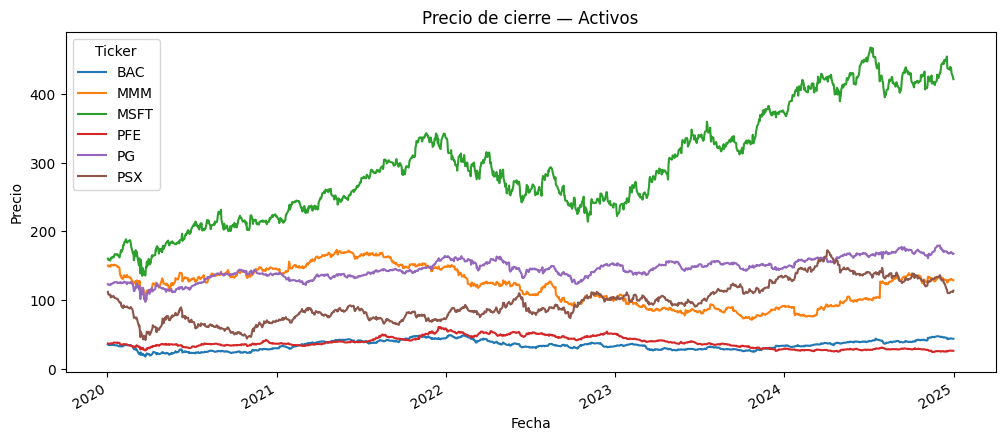

In [20]:
cierre = datos["Close"]

cierre.plot(figsize=(12, 5))
plt.title("Precio de cierre — Activos")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

### 👀 Observa

Describe brevemente lo que encuentras:

- ¿Se observan períodos de crecimiento o disminución?
- ¿Hay cambios especialmente fuertes?
- ¿El comportamiento parece estable durante todo el período?


# 5. 🔄 Medir los cambios

Comparar solamente precios puede ser insuficiente porque los activos pueden comenzar con valores muy diferentes.

Una alternativa es estudiar los **rendimientos**, que expresan el cambio de una observación respecto a la anterior.


### Cálculo de Rendimientos Financieros

Existen dos formas principales de calcular los rendimientos financieros: discretos y logarítmicos.

#### 1. Rendimientos Discretos (o Simples)

Los rendimientos discretos representan el cambio porcentual en el precio de un activo entre dos períodos consecutivos. Son intuitivos y fáciles de interpretar, ya que reflejan directamente la ganancia o pérdida en relación con el precio inicial. Son adecuados para el cálculo de rendimientos de un solo período.

La fórmula para el rendimiento discreto $R_t$ en el período $t$ es:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_{t-1}$ es el precio del activo en el tiempo $t-1$.

### Ejemplo de Cálculo de Rendimientos

Consideremos los siguientes precios:
*   Precio Anterior ($P_{t-1}$): **100**
*   Precio Actual ($P_t$): **110**

#### 1. Cálculo del Rendimiento Discreto

Utilizando la fórmula:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{110 - 100}{100} = \frac{10}{100} = 0.10$$

El rendimiento discreto es **0.10** o **10%**.


In [21]:
rendimiento = cierre.pct_change()
rendimiento.head()

Ticker,BAC,MMM,MSFT,PFE,PG,PSX
Date,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.020763,-0.008611,-0.012452,-0.005365,-0.006726,-0.033066
2020-01-06,-0.001433,0.000953,0.002585,-0.001284,0.001387,-0.006268
2020-01-07,-0.006600,-0.004031,-0.009118,-0.003344,-0.006191,0.003061
2020-01-08,0.010110,0.015346,0.015928,0.008000,0.004263,-0.037359


El primer valor aparece como `NaN` porque no existe una observación anterior con la cual compararlo.


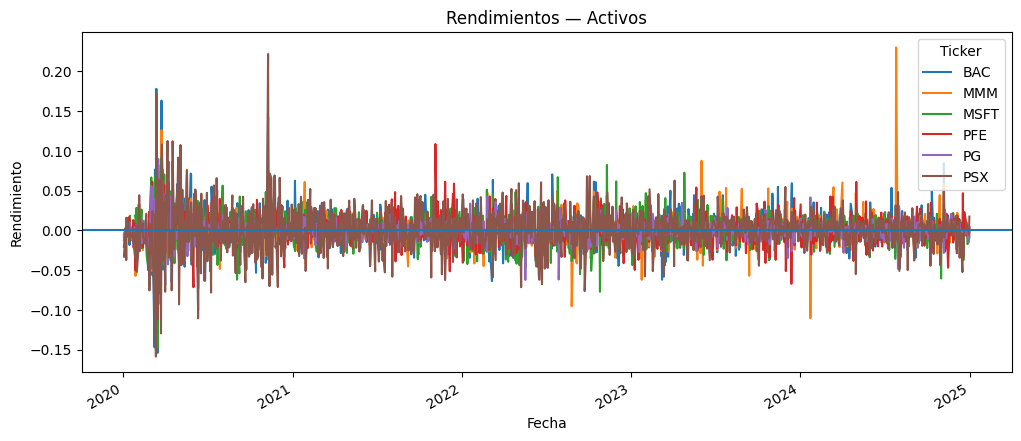

In [23]:
rendimiento.plot(figsize=(12, 5))

plt.axhline(0)
plt.title("Rendimientos — Activos")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.show()

# 6. 📐 Describir lo encontrado

Ahora podemos utilizar las estadísticas descriptivas para conocer mejor la distribución de los rendimientos.

In [24]:
rendimiento.describe()

Ticker,BAC,MMM,MSFT,PFE,PG,PSX
count,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000
mean,0.000419,0.000050,0.000953,-0.000117,0.000331,0.000375
std,0.022531,0.018666,0.019217,0.017405,0.013220,0.026958
min,-0.153973,-0.110350,-0.147390,-0.077346,-0.087373,-0.158658
25%,-0.010558,-0.008767,-0.008464,-0.009757,-0.005641,-0.012307
50%,0.000000,-0.000069,0.000965,-0.000866,0.000651,0.000410
75%,0.010809,0.008478,0.010932,0.008285,0.006833,0.014198
max,0.177962,0.229906,0.142169,0.108552,0.120090,0.221722


### Interpretación de las estadísticas descriptivas

La tabla `describe()` permite revisar, entre otros aspectos:

- **Mean (promedio):** rendimiento diario promedio del activo.
- **Std (desviación estándar):** dispersión de los rendimientos; puede utilizarse como una medida de volatilidad.
- **Min y Max:** los rendimientos diario mínimo y máximo observados.
- **25%, 50% y 75%:** percentiles que permiten conocer cómo se distribuyen los rendimientos.

En este ejercicio no se debe asumir que un activo tiene una determinada media, volatilidad o rendimiento extremo sin observar primero los resultados obtenidos para los activos asignados.

### ¿Cómo interpretar los resultados?

En general, los rendimientos diarios suelen fluctuar alrededor de un valor relativamente pequeño. Una mayor dispersión indica mayores cambios diarios en el precio.

La interpretación debe hacerse con los valores que arroje el conjunto de datos descargado de Yahoo Finance y no con cifras de un ejemplo diferente.

# Percentiles extremos


In [25]:
print("Percentil 1:", rendimiento.quantile(0.01))
print("Percentil 5:", rendimiento.quantile(0.05))

Percentil 1: Ticker
BAC    -0.057016
MMM    -0.048371
MSFT   -0.047823
PFE    -0.046642
PG     -0.040991
PSX    -0.073126
Name: 0.01, dtype: float64
Percentil 5: Ticker
BAC    -0.031665
MMM    -0.024988
MSFT   -0.028581
PFE    -0.024619
PG     -0.017517
PSX    -0.039961
Name: 0.05, dtype: float64


## Interpretación de percentiles y VaR

Los percentiles 1% y 5% permiten identificar rendimientos ubicados en la parte inferior de la distribución.

Como aproximación histórica:

- El **percentil 1%** indica un nivel de rendimiento que solo es igualado o superado hacia abajo por aproximadamente el 1% de las observaciones.
- El **percentil 5%** representa el nivel que deja aproximadamente el 5% de las observaciones por debajo.

Cuando se utilizan como una aproximación al **VaR histórico**, estos valores ayudan a describir pérdidas potenciales bajo el supuesto de que el comportamiento histórico es representativo. No deben interpretarse como una garantía de que una pérdida futura tendrá determinada probabilidad.

In [26]:
print("Promedio:", rendimiento.mean())
print("Desviación estándar:", rendimiento.std())
print("Mínimo:", rendimiento.min())
print("Máximo:", rendimiento.max())

Promedio: Ticker
BAC     0.000419
MMM     0.000050
MSFT    0.000953
PFE    -0.000117
PG      0.000331
PSX     0.000375
dtype: float64
Desviación estándar: Ticker
BAC     0.022531
MMM     0.018666
MSFT    0.019217
PFE     0.017405
PG      0.013220
PSX     0.026958
dtype: float64
Mínimo: Ticker
BAC    -0.153973
MMM    -0.110350
MSFT   -0.147390
PFE    -0.077346
PG     -0.087373
PSX    -0.158658
dtype: float64
Máximo: Ticker
BAC     0.177962
MMM     0.229906
MSFT    0.142169
PFE     0.108552
PG      0.120090
PSX     0.221722
dtype: float64


### 🧠 Interpreta

¿Qué nos dice el promedio? ¿Qué información aporta la desviación estándar? ¿Qué representan los valores mínimo y máximo?

Recuerda: **una estadística tiene sentido cuando podemos explicar qué significa en el contexto financiero.**

# 7. ⚖️ Comparar para comprender

Ahora incorporaremos varios activos. La comparación nos permitirá observar diferencias en su comportamiento.

In [27]:
# Descargar simultáneamente los seis activos asignados
activos = ["MSFT", "BAC", "PSX", "PFE", "PG", "MMM"]

datos = yf.download(
    activos,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False,
    group_by="column",
    progress=False
)

precios = datos["Close"]

print("Activos analizados:", activos)
print("Número de observaciones:", len(precios))
precios.head()

Activos analizados: ['MSFT', 'BAC', 'PSX', 'PFE', 'PG', 'MMM']
Número de observaciones: 1258


Ticker,BAC,MMM,MSFT,PFE,PG,PSX
Date,,,,,,
2020-01-02,35.639999,150.501678,160.619995,37.134724,123.410004,112.199997
2020-01-03,34.900002,149.205688,158.619995,36.935486,122.580002,108.489998
2020-01-06,34.849998,149.347824,159.029999,36.888046,122.750000,107.809998
2020-01-07,34.619999,148.745819,157.580002,36.764706,121.989998,108.139999
2020-01-08,34.970001,151.028427,160.089996,37.058823,122.510002,104.099998


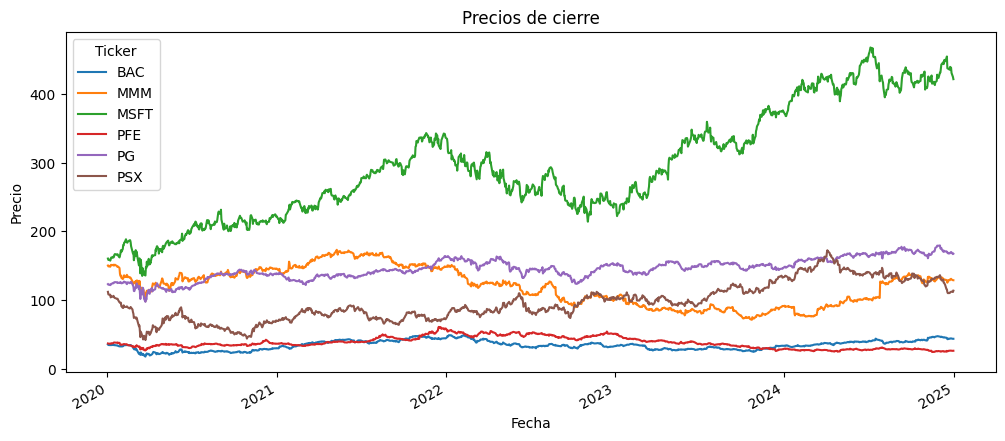

In [28]:
precios.plot(figsize=(12, 5))

plt.title("Precios de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

Los precios pueden tener escalas diferentes. Para comparar su evolución desde un mismo punto de referencia podemos construir un índice base 100.

### Normalización de Precios (Base 100)

Para comparar la evolución de diferentes activos financieros, es útil **normalizar sus precios a una base común**, como 100. Esto permite observar cómo ha crecido o disminuido el valor de cada activo desde un punto de partida equitativo, independientemente de sus precios absolutos iniciales.

La fórmula para normalizar un precio $P_t$ en el tiempo $t$ a una base 100 es:

$$\Large P_{t, \text{normalizado}} = \frac{P_t}{P_0} \times 100$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_0$ es el precio inicial (o precio en el punto de partida) del activo.

#### Ejemplo:

Supongamos que tenemos los siguientes precios para un activo en tres días:

*   Día 1 ($P_0$): **75.00**
*   Día 2 ($P_1$): **74.35**
*   Día 3 ($P_2$): **74.95**

Aplicando la fórmula de normalización:

*   **Día 1:** $\frac{75.00}{75.00} \times 100 = 100$
*   **Día 2:** $\frac{74.35}{75.00} \times 100 \approx 99.13$
*   **Día 3:** $\frac{74.95}{75.00} \times 100 \approx 99.93$

Estos valores normalizados nos permiten ver el cambio porcentual relativo de cada día respecto al día inicial (base 100).

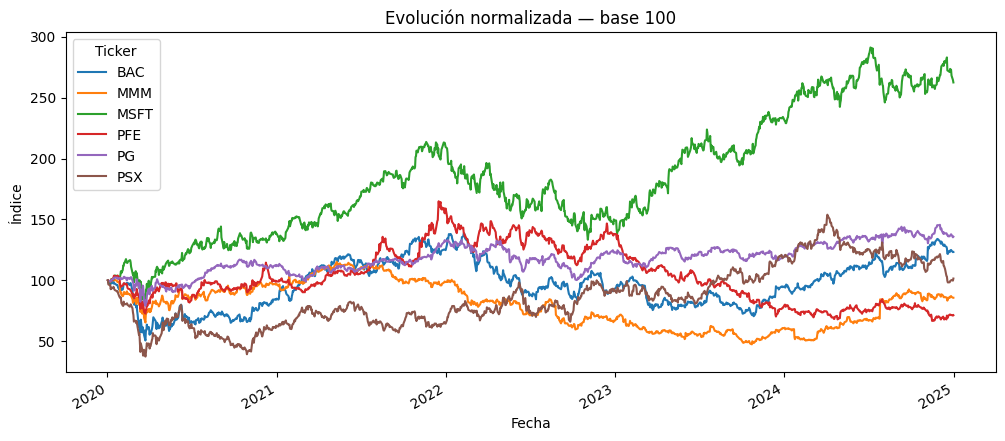

In [29]:
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución normalizada — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

# 8. 🔗 Buscar relaciones

En un portafolio no solo importa cómo se comporta cada activo individualmente. También interesa saber cómo se relacionan entre sí.

Primero calculamos los rendimientos de todos los activos.

In [30]:
rendimientos = precios.pct_change()
rendimientos.head()

Ticker,BAC,MMM,MSFT,PFE,PG,PSX
Date,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.020763,-0.008611,-0.012452,-0.005365,-0.006726,-0.033066
2020-01-06,-0.001433,0.000953,0.002585,-0.001284,0.001387,-0.006268
2020-01-07,-0.006600,-0.004031,-0.009118,-0.003344,-0.006191,0.003061
2020-01-08,0.010110,0.015346,0.015928,0.008000,0.004263,-0.037359


In [31]:
correlacion = rendimientos.corr()
correlacion

Ticker,BAC,MMM,MSFT,PFE,PG,PSX
Ticker,,,,,,
BAC,1.000000,0.518832,0.423019,0.319047,0.381613,0.603710
MMM,0.518832,1.000000,0.348269,0.317883,0.380962,0.366628
MSFT,0.423019,0.348269,1.000000,0.308321,0.456489,0.265103
PFE,0.319047,0.317883,0.308321,1.000000,0.387981,0.232201
PG,0.381613,0.380962,0.456489,0.387981,1.000000,0.190315
PSX,0.603710,0.366628,0.265103,0.232201,0.190315,1.000000


### Interpretación de la matriz de correlación

La correlación se encuentra entre -1 y 1:

- Cerca de **1**: los rendimientos tienden a moverse en la misma dirección.
- Cerca de **0**: existe una relación lineal débil.
- Cerca de **-1**: los rendimientos tienden a moverse en direcciones opuestas.

Para este ejercicio, la interpretación debe hacerse directamente sobre la matriz calculada para `MSFT`, `BAC`, `PSX`, `PFE`, `PG` y `MMM`. Una correlación elevada entre dos activos significa que sus movimientos históricos han tendido a ser similares, lo que puede reducir el efecto de diversificación entre esos dos activos. Esto describe una relación histórica y no garantiza que se mantenga en el futuro.

### ¿Cómo podemos leer la correlación?

- Cerca de **1**: los movimientos tienden a ser similares.
- Cerca de **0**: la relación lineal es débil.
- Cerca de **-1**: los movimientos tienden a ser opuestos.

### 💭 Pregunta

Si dos activos presentan una correlación elevada, ¿qué podría significar esto al pensar en diversificación?

# 9. 🚀 Tu análisis — activos asignados

Ahora realizaremos el análisis completo para:

**MSFT, BAC, PSX, PFE, PG y MMM**

La secuencia será:

**Obtener → Conocer → Explorar → Transformar → Describir → Comparar → Relacionar → Interpretar**

El siguiente código resume los principales resultados de los seis activos y facilita la elaboración de la conclusión.

ESTADÍSTICAS DE RENDIMIENTOS


,Promedio diario,Volatilidad (std),Mínimo diario,Máximo diario,Percentil 1%,Percentil 5%
Ticker,,,,,,
BAC,0.000419,0.022531,-0.153973,0.177962,-0.057016,-0.031665
MMM,0.000050,0.018666,-0.110350,0.229906,-0.048371,-0.024988
MSFT,0.000953,0.019217,-0.147390,0.142169,-0.047823,-0.028581
PFE,-0.000117,0.017405,-0.077346,0.108552,-0.046642,-0.024619
PG,0.000331,0.013220,-0.087373,0.120090,-0.040991,-0.017517
PSX,0.000375,0.026958,-0.158658,0.221722,-0.073126,-0.039961



RENDIMIENTO ACUMULADO DEL PRECIO


,Rendimiento acumulado
Ticker,
MSFT,1.624206
PG,0.358480
BAC,0.233165
PSX,0.015419
MMM,-0.142269
PFE,-0.285574



MATRIZ DE CORRELACIÓN


Ticker,BAC,MMM,MSFT,PFE,PG,PSX
Ticker,,,,,,
BAC,1.000000,0.518832,0.423019,0.319047,0.381613,0.603710
MMM,0.518832,1.000000,0.348269,0.317883,0.380962,0.366628
MSFT,0.423019,0.348269,1.000000,0.308321,0.456489,0.265103
PFE,0.319047,0.317883,0.308321,1.000000,0.387981,0.232201
PG,0.381613,0.380962,0.456489,0.387981,1.000000,0.190315
PSX,0.603710,0.366628,0.265103,0.232201,0.190315,1.000000


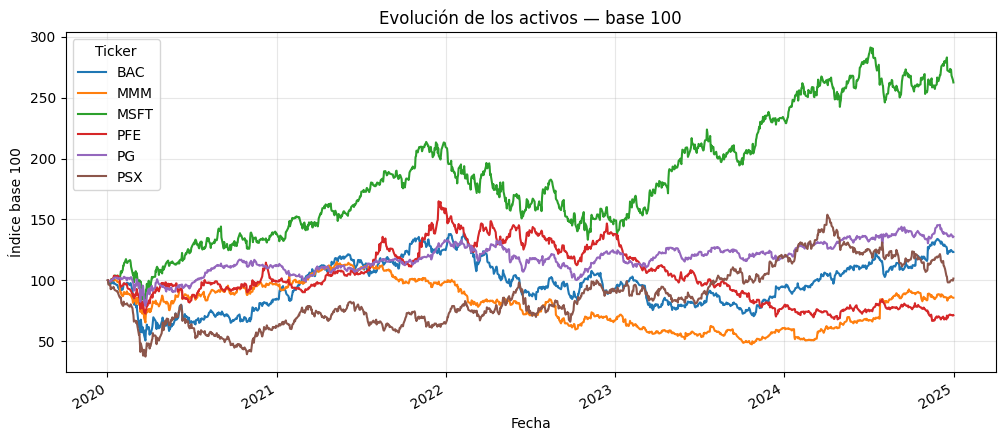

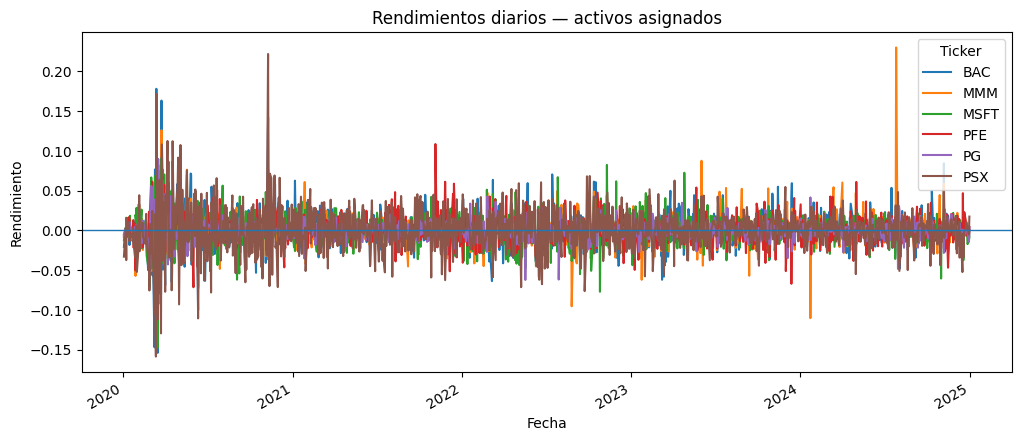


CONCLUSIÓN:
Encontré que…
La información que más me ayudó a comparar los activos fue…
Antes de construir un portafolio, considero importante revisar…


In [32]:
# ============================================================
# RESUMEN FINAL DEL ANÁLISIS
# ============================================================

# 1. Rendimientos diarios
rendimientos = precios.pct_change()

# 2. Estadísticas descriptivas de los rendimientos
estadisticas = pd.DataFrame({
    "Promedio diario": rendimientos.mean(),
    "Volatilidad (std)": rendimientos.std(),
    "Mínimo diario": rendimientos.min(),
    "Máximo diario": rendimientos.max(),
    "Percentil 1%": rendimientos.quantile(0.01),
    "Percentil 5%": rendimientos.quantile(0.05)
})

print("ESTADÍSTICAS DE RENDIMIENTOS")
display(estadisticas)

# 3. Rendimiento acumulado aproximado del precio de cierre
rendimiento_acumulado = (precios.iloc[-1] / precios.iloc[0]) - 1
print("\nRENDIMIENTO ACUMULADO DEL PRECIO")
display(rendimiento_acumulado.sort_values(ascending=False).to_frame("Rendimiento acumulado"))

# 4. Correlación
print("\nMATRIZ DE CORRELACIÓN")
display(rendimientos.corr())

# 5. Gráfico de precios normalizados
precios_normalizados = precios / precios.iloc[0] * 100
precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución de los activos — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice base 100")
plt.grid(True, alpha=0.3)
plt.show()

# 6. Gráfico de rendimientos
rendimientos.plot(figsize=(12, 5))
plt.axhline(0, linewidth=1)
plt.title("Rendimientos diarios — activos asignados")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.show()

# 7. Frases para construir la conclusión
print("\nCONCLUSIÓN:")
print("Encontré que…")
print("La información que más me ayudó a comparar los activos fue…")
print("Antes de construir un portafolio, considero importante revisar…")

### ✍️ Guía para redactar la conclusión

Para responder la pregunta final, utiliza los resultados reales obtenidos arriba. Puedes mencionar:

1. Qué activos tuvieron mayores y menores cambios acumulados.
2. Cuáles mostraron mayor o menor volatilidad según la desviación estándar.
3. Qué pares presentaron correlaciones más altas o más bajas.
4. Por qué comparar rendimientos y no solamente precios permite una comparación más justa.
5. Qué importancia tienen la volatilidad, los rendimientos y la correlación al estudiar un portafolio.

**Importante:** la conclusión debe basarse en los valores que aparezcan al ejecutar el notebook.


Al realizar el análisis de los diferentes activos pude observar que cada uno tuvo un comportamiento diferente durante el período estudiado. MSFT fue el activo que tuvo el mayor crecimiento acumulado, con 1,624206, mientras que PFE presentó el resultado más bajo, con -0,285574. También se pudo observar que PG tuvo una menor variación en sus rendimientos, con una desviación estándar de 0,013220, mientras que PSX presentó la mayor, con 0,026958.

En cuanto a la relación entre los activos, la mayor correlación se presentó entre BAC y PSX, con 0,603710, mientras que la menor fue entre PG y PSX, con 0,190315. Esto permite ver que algunos activos tuvieron movimientos más parecidos que otros, pero ninguno tuvo una relación completamente igual.

También pude entender que es más útil comparar los rendimientos que solamente los precios de las acciones, porque los precios de cada empresa pueden ser muy diferentes y esto no permite comparar fácilmente cuál tuvo un mejor comportamiento. Los rendimientos muestran de una manera más clara cuánto aumentó o disminuyó cada activo.

En conclusión, este análisis me permitió entender que para estudiar un grupo de inversiones no es suficiente mirar solamente cuál subió más. También es importante observar cuánto varían sus rendimientos y qué relación tienen con los demás activos. De esta manera se puede tener una idea más completa del comportamiento de un portafolio y de las diferencias que existen entre las opciones analizadas.
